In [87]:
import numpy as np
import matplotlib.pyplot as plt

## Part A and B:

#### For v = 0.1c

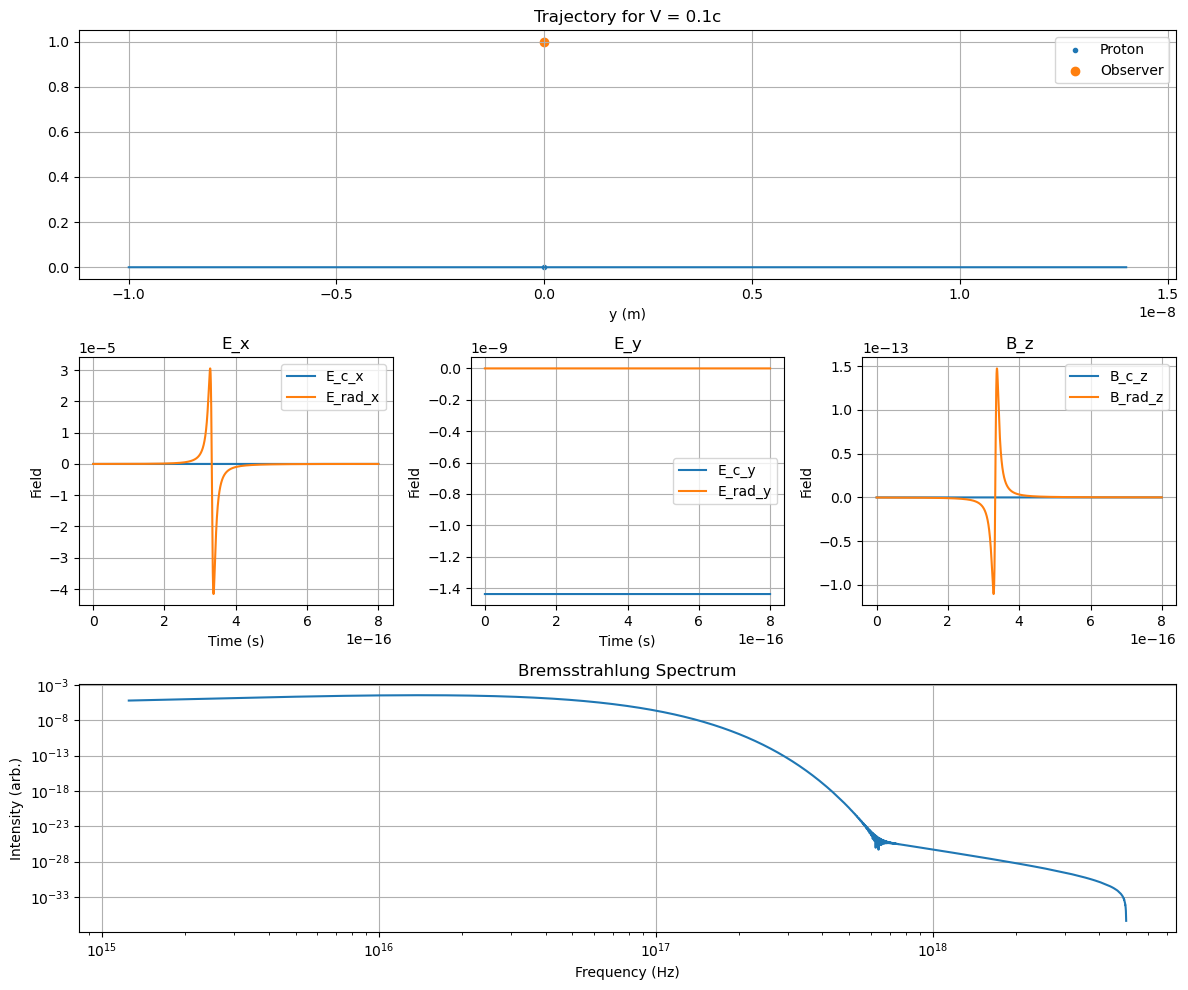

In [97]:
# ================= CONSTANTS =================
e = 1.6e-19
eps0 = 8.854e-12
m = 9.11e-31
c = 3e8

# ================= INITIAL CONDITIONS =================
x, y = -10e-9, 2e-10
vx, vy = 0.1*c, 0.0

xp, yp = 0.0, 0.0
xo, yo = 0.0, 1

dt = 1e-19
steps = 8000

# ================= STORAGE =================
xs, ys = [], []
Ex_c, Ey_c, Bz_c = [], [], []
Erad_x, Erad_y, Brad_z = [], [], []
time = []

# ================= FUNCTIONS =================

def E_proton(x, y):
    rx, ry = x - xp, y - yp
    r = np.sqrt(rx**2 + ry**2) + 1e-20
    Ex = (e / (4*np.pi*eps0)) * rx / r**3
    Ey = (e / (4*np.pi*eps0)) * ry / r**3
    return Ex, Ey

def coulomb_field_obs(xe, ye, vxe, vye):
    Rx, Ry = xo - xe, yo - ye
    R = np.sqrt(Rx**2 + Ry**2) + 1e-20

    Ex = (-e / (4*np.pi*eps0)) * Rx / R**3
    Ey = (-e / (4*np.pi*eps0)) * Ry / R**3
    Bz = (vxe * Ey - vye * Ex) / c**2

    return Ex, Ey, Bz

# ================= EULER LOOP =================

for i in range(steps):

    Ex_p, Ey_p = E_proton(x, y)

    v2 = vx**2 + vy**2
    gamma = 1 / np.sqrt(1 - v2/c**2)

    dot = vx*Ex_p + vy*Ey_p

    ax = (-e/(gamma*m)) * (Ex_p - vx*dot/c**2)
    ay = (-e/(gamma*m)) * (Ey_p - vy*dot/c**2)

    vx += ax * dt
    vy += ay * dt
    x += vx * dt
    y += vy * dt

    Exo, Eyo, Bzo = coulomb_field_obs(x, y, vx, vy)

    Rx, Ry = xo - x, yo - y
    R = np.sqrt(Rx**2 + Ry**2) + 1e-20

    nx, ny = Rx/R, Ry/R

    betax, betay = vx/c, vy/c
    betadotx, betadoty = ax/c, ay/c

    nbx = nx - betax
    nby = ny - betay

    cross1_z = nbx * betadoty - nby * betadotx

    Ex_rad = ny * cross1_z
    Ey_rad = -nx * cross1_z

    denom = (1 - (nx*betax + ny*betay))**3

    prefactor = -e / (4*np.pi*eps0 * c)

    Ex_rad = prefactor * Ex_rad / (denom * R)
    Ey_rad = prefactor * Ey_rad / (denom * R)

    Bz_rad = (nx * Ey_rad - ny * Ex_rad) / c

    xs.append(x)
    ys.append(y)

    Ex_c.append(Exo)
    Ey_c.append(Eyo)
    Bz_c.append(Bzo)

    Erad_x.append(Ex_rad)
    Erad_y.append(Ey_rad)
    Brad_z.append(Bz_rad)

    time.append(i*dt)

# ================= SPECTRUM =================

Erad_x = np.array(Erad_x)
Erad_y = np.array(Erad_y)
time_arr = np.array(time)

window = np.hanning(len(Erad_x))
Erad_x = Erad_x * window
Erad_y = Erad_y * window

dt = time_arr[1] - time_arr[0]

Ex_w = np.fft.fft(Erad_x)
Ey_w = np.fft.fft(Erad_y)

freq = np.fft.fftfreq(len(time_arr), dt)
mask = freq > 0

freq = freq[mask]
I_w = (np.abs(Ex_w)**2 + np.abs(Ey_w)**2)[mask]

g_ff = 1
I_w *= g_ff

# ================= PLOTTING =================

fig = plt.figure(figsize=(12, 10))

ax1 = plt.subplot2grid((3,3), (0,0), colspan=3)
ax1.plot(xs, ys)
ax1.scatter([xp], [yp], label='Proton', marker='.')
ax1.scatter([xo], [yo], label='Observer')
ax1.set_title("Trajectory for V = 0.1c")
ax1.set_xlabel("x (m)")
ax1.set_xlabel("y (m)")
ax1.legend()
ax1.grid()

ax2 = plt.subplot2grid((3,3), (1,0))
ax2.plot(time, Ex_c, label="E_c_x")
ax2.plot(time, Erad_x, label="E_rad_x")
ax2.set_title("E_x")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Field")
ax2.legend()
ax2.grid()

ax3 = plt.subplot2grid((3,3), (1,1))
ax3.plot(time, Ey_c, label="E_c_y")
ax3.plot(time, Erad_y, label="E_rad_y")
ax3.set_title("E_y")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Field")
ax3.legend()
ax3.grid()

ax4 = plt.subplot2grid((3,3), (1,2))
ax4.plot(time, Bz_c, label="B_c_z")
ax4.plot(time, Brad_z, label="B_rad_z")
ax4.set_title("B_z")
ax4.set_ylabel("Time (s)")
ax4.set_ylabel("Field")
ax4.legend()
ax4.grid()

ax5 = plt.subplot2grid((3,3), (2,0), colspan=3)
ax5.loglog(freq, I_w)
ax5.set_title("Bremsstrahlung Spectrum")
ax5.set_xlabel("Frequency (Hz)")
ax5.set_ylabel("Intensity (arb.)")
ax5.grid()

plt.tight_layout()
plt.show()

#### For V = 0.999c

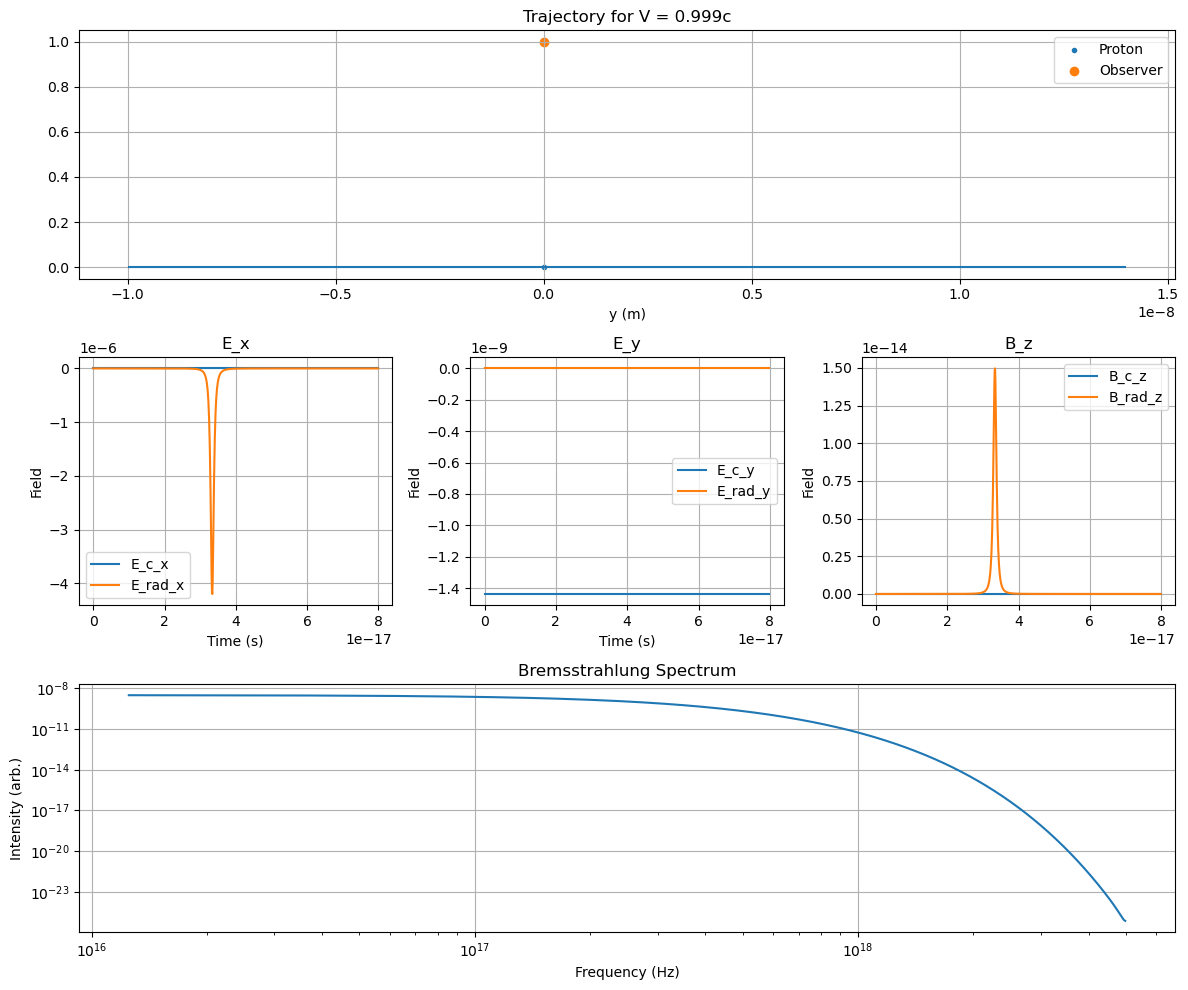

In [103]:
# ================= CONSTANTS =================
e = 1.6e-19
eps0 = 8.854e-12
m = 9.11e-31
c = 3e8

# ================= INITIAL CONDITIONS =================
x, y = -10e-9, 2e-10
vx, vy = 0.999*c, 0.0

xp, yp = 0.0, 0.0
xo, yo = 0.0, 1

dt = 1e-19
steps = 800

# ================= STORAGE =================
xs, ys = [], []
Ex_c, Ey_c, Bz_c = [], [], []
Erad_x, Erad_y, Brad_z = [], [], []
time = []

# ================= FUNCTIONS =================

def E_proton(x, y):
    rx, ry = x - xp, y - yp
    r = np.sqrt(rx**2 + ry**2) + 1e-20
    Ex = (e / (4*np.pi*eps0)) * rx / r**3
    Ey = (e / (4*np.pi*eps0)) * ry / r**3
    return Ex, Ey

def coulomb_field_obs(xe, ye, vxe, vye):
    Rx, Ry = xo - xe, yo - ye
    R = np.sqrt(Rx**2 + Ry**2) + 1e-20

    Ex = (-e / (4*np.pi*eps0)) * Rx / R**3
    Ey = (-e / (4*np.pi*eps0)) * Ry / R**3
    Bz = (vxe * Ey - vye * Ex) / c**2

    return Ex, Ey, Bz

# ================= EULER LOOP =================

for i in range(steps):

    Ex_p, Ey_p = E_proton(x, y)

    v2 = vx**2 + vy**2
    gamma = 1 / np.sqrt(1 - v2/c**2)

    dot = vx*Ex_p + vy*Ey_p

    ax = (-e/(gamma*m)) * (Ex_p - vx*dot/c**2)
    ay = (-e/(gamma*m)) * (Ey_p - vy*dot/c**2)

    vx += ax * dt
    vy += ay * dt
    x += vx * dt
    y += vy * dt

    Exo, Eyo, Bzo = coulomb_field_obs(x, y, vx, vy)

    Rx, Ry = xo - x, yo - y
    R = np.sqrt(Rx**2 + Ry**2) + 1e-20

    nx, ny = Rx/R, Ry/R

    betax, betay = vx/c, vy/c
    betadotx, betadoty = ax/c, ay/c

    nbx = nx - betax
    nby = ny - betay

    cross1_z = nbx * betadoty - nby * betadotx

    Ex_rad = ny * cross1_z
    Ey_rad = -nx * cross1_z

    denom = (1 - (nx*betax + ny*betay))**3

    prefactor = -e / (4*np.pi*eps0 * c)

    Ex_rad = prefactor * Ex_rad / (denom * R)
    Ey_rad = prefactor * Ey_rad / (denom * R)

    Bz_rad = (nx * Ey_rad - ny * Ex_rad) / c

    xs.append(x)
    ys.append(y)

    Ex_c.append(Exo)
    Ey_c.append(Eyo)
    Bz_c.append(Bzo)

    Erad_x.append(Ex_rad)
    Erad_y.append(Ey_rad)
    Brad_z.append(Bz_rad)

    time.append(i*dt)

# ================= SPECTRUM =================

Erad_x = np.array(Erad_x)
Erad_y = np.array(Erad_y)
time_arr = np.array(time)

window = np.hanning(len(Erad_x))
Erad_x = Erad_x * window
Erad_y = Erad_y * window

dt = time_arr[1] - time_arr[0]

Ex_w = np.fft.fft(Erad_x)
Ey_w = np.fft.fft(Erad_y)

freq = np.fft.fftfreq(len(time_arr), dt)
mask = freq > 0

freq = freq[mask]
I_w = (np.abs(Ex_w)**2 + np.abs(Ey_w)**2)[mask]

g_ff = 1
I_w *= g_ff

# ================= PLOTTING =================

fig = plt.figure(figsize=(12, 10))

ax1 = plt.subplot2grid((3,3), (0,0), colspan=3)
ax1.plot(xs, ys)
ax1.scatter([xp], [yp], label='Proton', marker='.')
ax1.scatter([xo], [yo], label='Observer')
ax1.set_title("Trajectory for V = 0.999c")
ax1.set_xlabel("x (m)")
ax1.set_xlabel("y (m)")
ax1.legend()
ax1.grid()

ax2 = plt.subplot2grid((3,3), (1,0))
ax2.plot(time, Ex_c, label="E_c_x")
ax2.plot(time, Erad_x, label="E_rad_x")
ax2.set_title("E_x")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Field")
ax2.legend()
ax2.grid()

ax3 = plt.subplot2grid((3,3), (1,1))
ax3.plot(time, Ey_c, label="E_c_y")
ax3.plot(time, Erad_y, label="E_rad_y")
ax3.set_title("E_y")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Field")
ax3.legend()
ax3.grid()

ax4 = plt.subplot2grid((3,3), (1,2))
ax4.plot(time, Bz_c, label="B_c_z")
ax4.plot(time, Brad_z, label="B_rad_z")
ax4.set_title("B_z")
ax4.set_ylabel("Time (s)")
ax4.set_ylabel("Field")
ax4.legend()
ax4.grid()

ax5 = plt.subplot2grid((3,3), (2,0), colspan=3)
ax5.loglog(freq, I_w)
ax5.set_title("Bremsstrahlung Spectrum")
ax5.set_xlabel("Frequency (Hz)")
ax5.set_ylabel("Intensity (arb.)")
ax5.grid()

plt.tight_layout()
plt.show()

#### Additional case when v = 0.5c. I added this because it shows the signal due to both the front and back lobe of the emission. The front lobe is the large spike in the E and B. The small spike is due to the backward lobe of the emission.

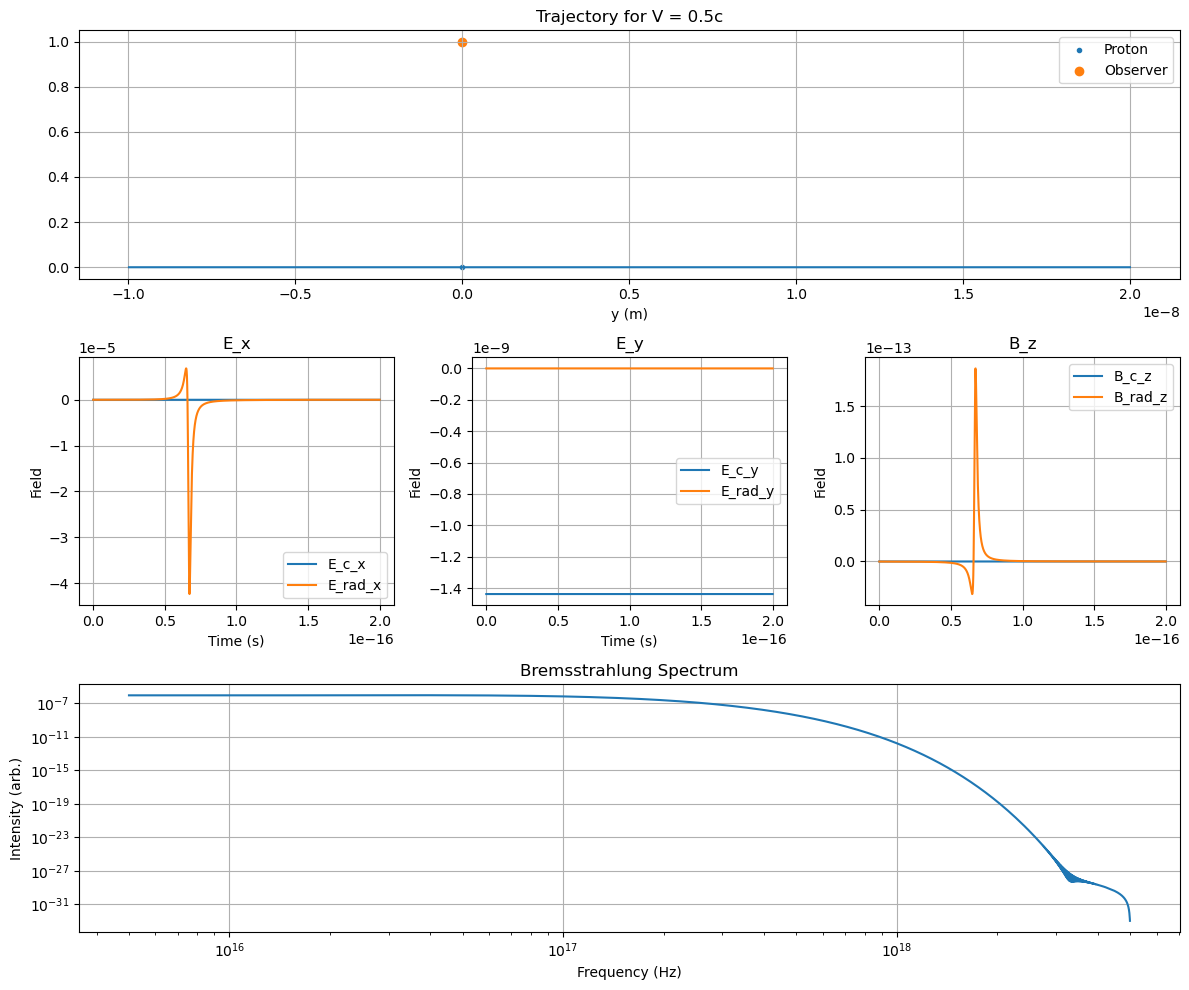

In [101]:
# ================= CONSTANTS =================
e = 1.6e-19
eps0 = 8.854e-12
m = 9.11e-31
c = 3e8

# ================= INITIAL CONDITIONS =================
x, y = -10e-9, 2e-10
vx, vy = 0.5*c, 0.0

xp, yp = 0.0, 0.0
xo, yo = 0.0, 1

dt = 1e-19
steps = 2000

# ================= STORAGE =================
xs, ys = [], []
Ex_c, Ey_c, Bz_c = [], [], []
Erad_x, Erad_y, Brad_z = [], [], []
time = []

# ================= FUNCTIONS =================

def E_proton(x, y):
    rx, ry = x - xp, y - yp
    r = np.sqrt(rx**2 + ry**2) + 1e-20
    Ex = (e / (4*np.pi*eps0)) * rx / r**3
    Ey = (e / (4*np.pi*eps0)) * ry / r**3
    return Ex, Ey

def coulomb_field_obs(xe, ye, vxe, vye):
    Rx, Ry = xo - xe, yo - ye
    R = np.sqrt(Rx**2 + Ry**2) + 1e-20

    Ex = (-e / (4*np.pi*eps0)) * Rx / R**3
    Ey = (-e / (4*np.pi*eps0)) * Ry / R**3
    Bz = (vxe * Ey - vye * Ex) / c**2

    return Ex, Ey, Bz

# ================= EULER LOOP =================

for i in range(steps):

    Ex_p, Ey_p = E_proton(x, y)

    v2 = vx**2 + vy**2
    gamma = 1 / np.sqrt(1 - v2/c**2)

    dot = vx*Ex_p + vy*Ey_p

    ax = (-e/(gamma*m)) * (Ex_p - vx*dot/c**2)
    ay = (-e/(gamma*m)) * (Ey_p - vy*dot/c**2)

    vx += ax * dt
    vy += ay * dt
    x += vx * dt
    y += vy * dt

    Exo, Eyo, Bzo = coulomb_field_obs(x, y, vx, vy)

    Rx, Ry = xo - x, yo - y
    R = np.sqrt(Rx**2 + Ry**2) + 1e-20

    nx, ny = Rx/R, Ry/R

    betax, betay = vx/c, vy/c
    betadotx, betadoty = ax/c, ay/c

    nbx = nx - betax
    nby = ny - betay

    cross1_z = nbx * betadoty - nby * betadotx

    Ex_rad = ny * cross1_z
    Ey_rad = -nx * cross1_z

    denom = (1 - (nx*betax + ny*betay))**3

    prefactor = -e / (4*np.pi*eps0 * c)

    Ex_rad = prefactor * Ex_rad / (denom * R)
    Ey_rad = prefactor * Ey_rad / (denom * R)

    Bz_rad = (nx * Ey_rad - ny * Ex_rad) / c

    xs.append(x)
    ys.append(y)

    Ex_c.append(Exo)
    Ey_c.append(Eyo)
    Bz_c.append(Bzo)

    Erad_x.append(Ex_rad)
    Erad_y.append(Ey_rad)
    Brad_z.append(Bz_rad)

    time.append(i*dt)

# ================= SPECTRUM =================

Erad_x = np.array(Erad_x)
Erad_y = np.array(Erad_y)
time_arr = np.array(time)

window = np.hanning(len(Erad_x))
Erad_x = Erad_x * window
Erad_y = Erad_y * window

dt = time_arr[1] - time_arr[0]

Ex_w = np.fft.fft(Erad_x)
Ey_w = np.fft.fft(Erad_y)

freq = np.fft.fftfreq(len(time_arr), dt)
mask = freq > 0

freq = freq[mask]
I_w = (np.abs(Ex_w)**2 + np.abs(Ey_w)**2)[mask]

g_ff = 1
I_w *= g_ff

# ================= PLOTTING =================

fig = plt.figure(figsize=(12, 10))

ax1 = plt.subplot2grid((3,3), (0,0), colspan=3)
ax1.plot(xs, ys)
ax1.scatter([xp], [yp], label='Proton', marker='.')
ax1.scatter([xo], [yo], label='Observer')
ax1.set_title("Trajectory for V = 0.5c")
ax1.set_xlabel("x (m)")
ax1.set_xlabel("y (m)")
ax1.legend()
ax1.grid()

ax2 = plt.subplot2grid((3,3), (1,0))
ax2.plot(time, Ex_c, label="E_c_x")
ax2.plot(time, Erad_x, label="E_rad_x")
ax2.set_title("E_x")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Field")
ax2.legend()
ax2.grid()

ax3 = plt.subplot2grid((3,3), (1,1))
ax3.plot(time, Ey_c, label="E_c_y")
ax3.plot(time, Erad_y, label="E_rad_y")
ax3.set_title("E_y")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Field")
ax3.legend()
ax3.grid()

ax4 = plt.subplot2grid((3,3), (1,2))
ax4.plot(time, Bz_c, label="B_c_z")
ax4.plot(time, Brad_z, label="B_rad_z")
ax4.set_title("B_z")
ax4.set_ylabel("Time (s)")
ax4.set_ylabel("Field")
ax4.legend()
ax4.grid()

ax5 = plt.subplot2grid((3,3), (2,0), colspan=3)
ax5.loglog(freq, I_w)
ax5.set_title("Bremsstrahlung Spectrum")
ax5.set_xlabel("Frequency (Hz)")
ax5.set_ylabel("Intensity (arb.)")
ax5.grid()

plt.tight_layout()
plt.show()